# Iris Flower Classification

**Objective:** Train and compare machine learning classifiers to predict the species of an iris flower
(*Setosa*, *Versicolor*, *Virginica*) from four physical measurements: sepal length, sepal width,
petal length, and petal width.

**Workflow:**
1. Load data
2. Exploratory Data Analysis (EDA)
3. Visualisations
4. Feature selection discussion
5. Train/test split
6. Train multiple classifiers
7. Evaluate & compare
8. Declare the best model


## 1. Imports

In [20]:
import sys
print(sys.executable)

c:\Users\VENKAT\AppData\Local\Programs\Python\Python314\python.exe


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")


## 2. Load the Dataset

The Iris dataset ships directly with scikit-learn, so no external download is required.

In [22]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


## 3. Exploratory Data Analysis (EDA)

### 3.1 Shape and data types

In [23]:
print("Shape (rows, columns):", df.shape)
print()
print("Data types:")
print(df.dtypes)


Shape (rows, columns): (150, 5)

Data types:
sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object


### 3.2 Null value check

In [24]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Total missing values:", df.isnull().sum().sum())


Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Total missing values: 0


### 3.3 Descriptive statistics

In [25]:
print(df.describe())


       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


### 3.4 Class balance

In [26]:
print(df['species'].value_counts())


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


The dataset is **perfectly balanced**: 50 samples for each of the three species, and there are **no missing values** — no imputation or resampling is needed.

## 4. Visualisations

### 4.1 Pairplot / scatter matrix
Shows how each pair of features separates the three species.

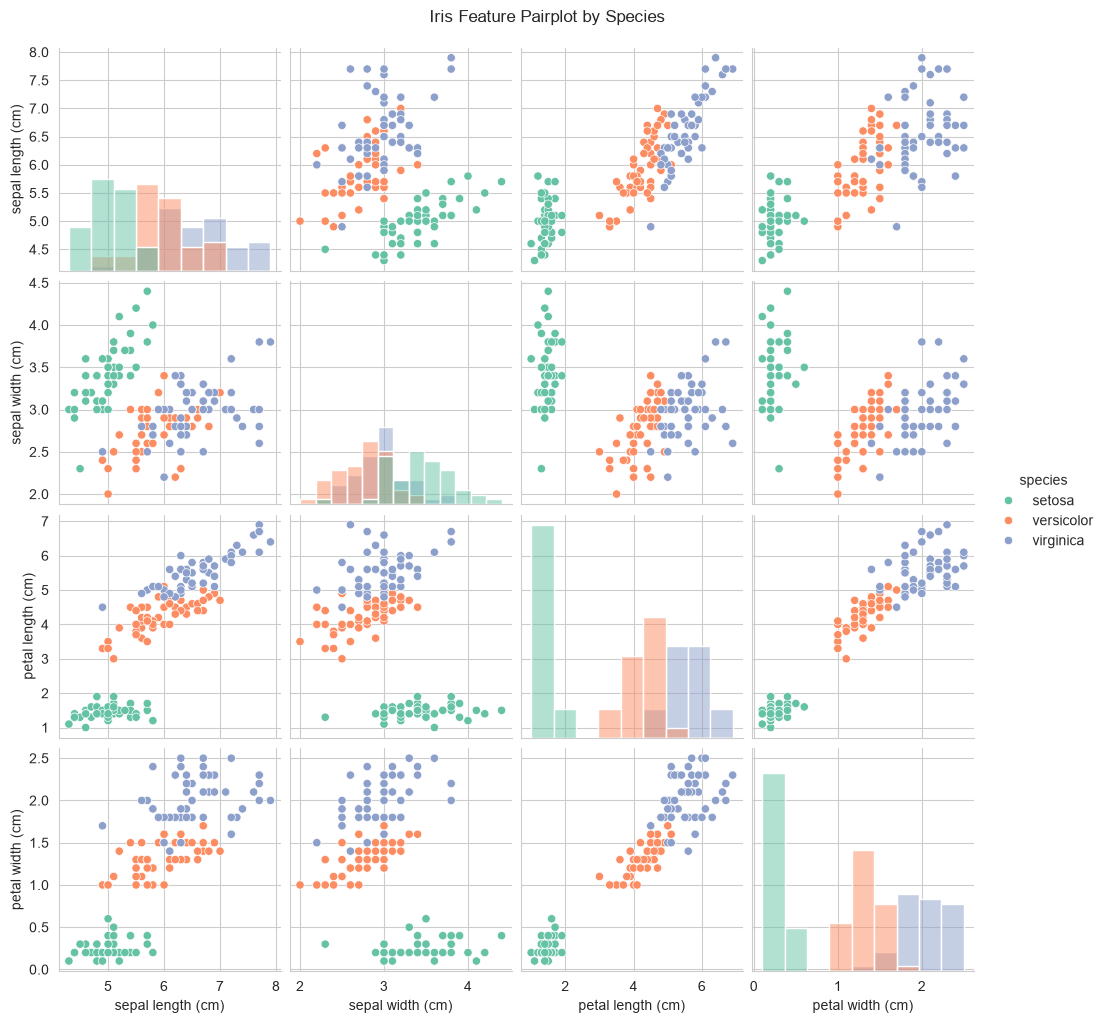

In [27]:
g = sns.pairplot(df, hue='species', diag_kind='hist', palette='Set2', corner=False)
g.fig.suptitle("Iris Feature Pairplot by Species", y=1.02)
plt.show()


### 4.2 Box plots for each feature

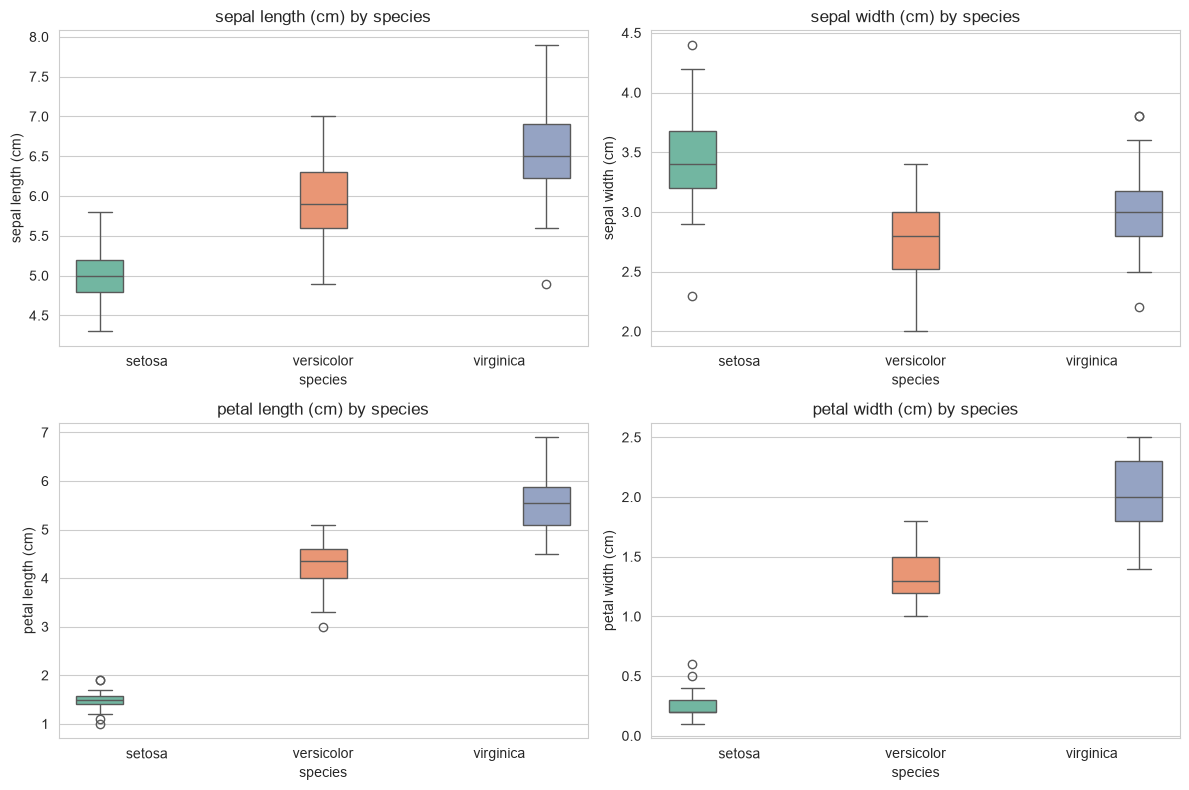

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = iris.feature_names

for ax, feat in zip(axes.flat, features):
    sns.boxplot(data=df, x='species', y=feat, hue='species', palette='Set2', legend=False, ax=ax)
    ax.set_title(f"{feat} by species")

plt.tight_layout()
plt.show()


### 4.3 Feature correlation heatmap

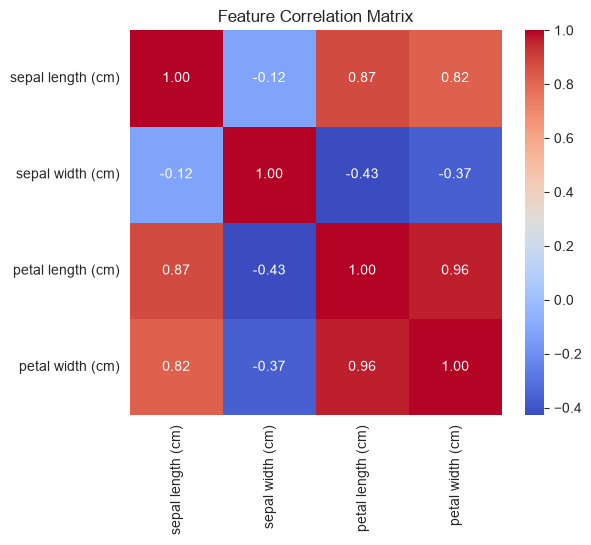

In [29]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[iris.feature_names].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()


## 5. Feature Selection Discussion

Looking at the pairplot and box plots:

- **Petal length** and **petal width** show almost no overlap between species (especially Setosa,
  which is perfectly separable on these two alone) — these are the **most discriminative** features.
- **Sepal length** is moderately useful but the species overlap more, particularly Versicolor vs Virginica.
- **Sepal width** shows the most overlap across all three species and is the **least discriminative**
  feature on its own.
- The correlation heatmap confirms petal length and petal width are highly correlated with each other
  (and with sepal length), while sepal width is only weakly correlated with the rest.

**Conclusion:** all four features are kept for modelling (the dataset is small and low-dimensional, so
there's no cost to including sepal width), but if a minimal feature set were required, *petal length*
and *petal width* alone would likely achieve strong accuracy.

## 6. Train/Test Split (80/20)

In [30]:
X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (120, 4)
Test set size: (30, 4)


`stratify=y` ensures the 80/20 split preserves the original class balance in both the train and test sets.

Some models (Logistic Regression, KNN) are distance/gradient based and benefit from feature scaling.
Tree-based models (Decision Tree, Random Forest) are scale-invariant, so they are trained on the
original (unscaled) features.

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 7. Train Multiple Classifiers

Four classifiers are trained and compared: Logistic Regression, K-Nearest Neighbours,
Decision Tree, and Random Forest.

In [32]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

# Which models need the scaled features
scaled_models = {"Logistic Regression", "K-Nearest Neighbors"}

trained_models = {}
predictions = {}

for name, model in models.items():
    if name in scaled_models:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    trained_models[name] = model
    predictions[name] = preds

print("Models trained:", list(models.keys()))


Models trained: ['Logistic Regression', 'K-Nearest Neighbors', 'Decision Tree', 'Random Forest']


## 8. Evaluation

In [33]:
results = {}

for name, preds in predictions.items():
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n{'='*60}")
    print(f"Model: {name}")
    print(f"{'='*60}")
    print(f"Accuracy: {acc:.4f}\n")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))
    print()
    print("Classification Report:")
    print(classification_report(y_test, preds))



Model: Logistic Regression
Accuracy: 0.9333

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Model: K-Nearest Neighbors
Accuracy: 0.9333

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93

### 8.1 Confusion matrices (visual)

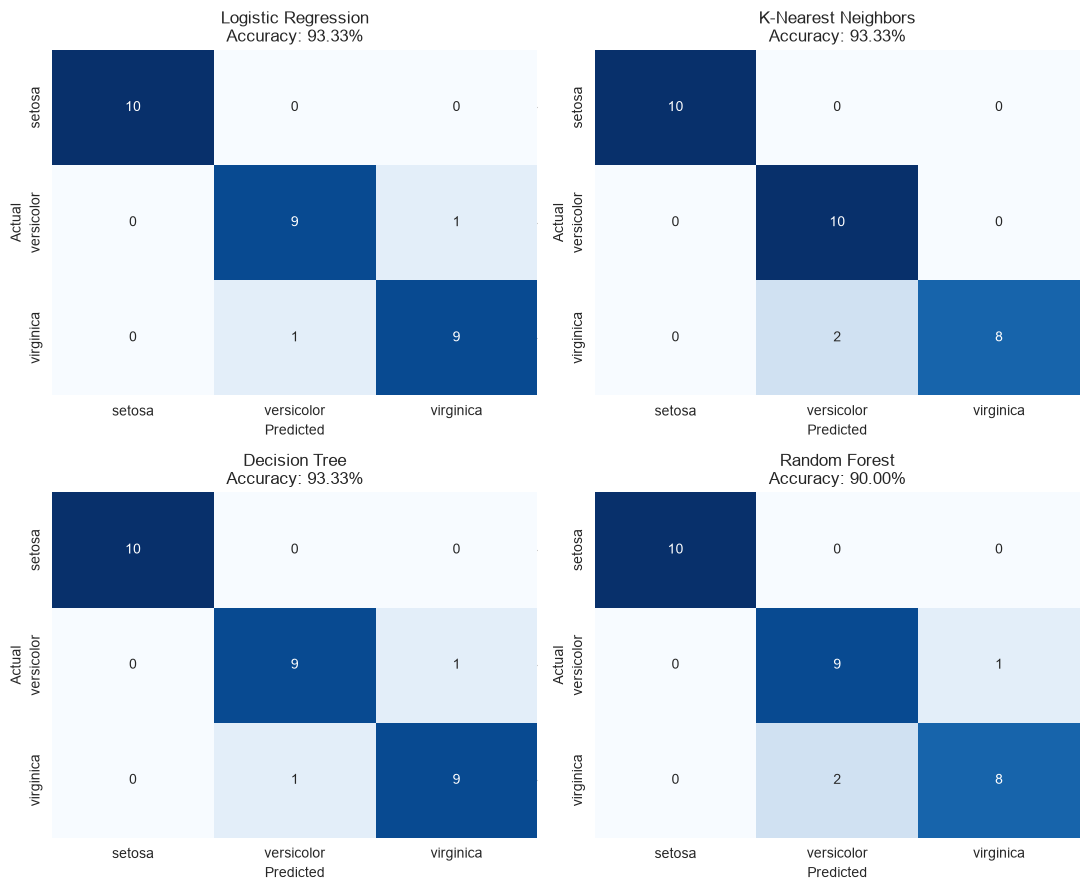

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
labels = iris.target_names

for ax, (name, preds) in zip(axes.flat, predictions.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)
    ax.set_title(f"{name}\nAccuracy: {results[name]:.2%}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


### 8.2 Accuracy comparison

Logistic Regression    0.933333
K-Nearest Neighbors    0.933333
Decision Tree          0.933333
Random Forest          0.900000
Name: Accuracy, dtype: float64


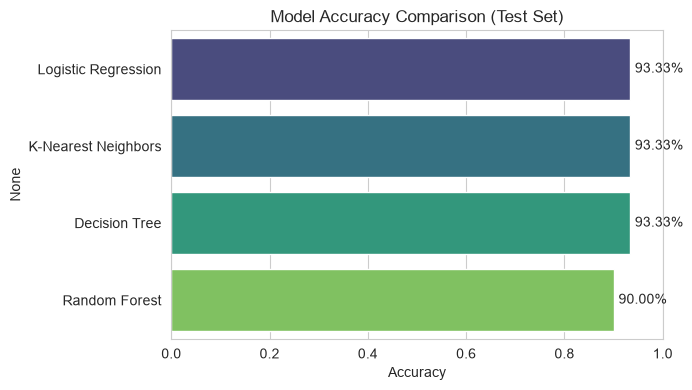

In [35]:
results_df = pd.Series(results, name="Accuracy").sort_values(ascending=False)
print(results_df)

plt.figure(figsize=(7, 4))
sns.barplot(x=results_df.values, y=results_df.index, hue=results_df.index, palette='viridis', legend=False)
plt.xlabel("Accuracy")
plt.xlim(0, 1)
for i, v in enumerate(results_df.values):
    plt.text(v + 0.01, i, f"{v:.2%}", va='center')
plt.title("Model Accuracy Comparison (Test Set)")
plt.tight_layout()
plt.show()


### 8.3 Feature importance (Random Forest)

petal width (cm)     0.437185
petal length (cm)    0.431466
sepal length (cm)    0.116349
sepal width (cm)     0.015000
dtype: float64


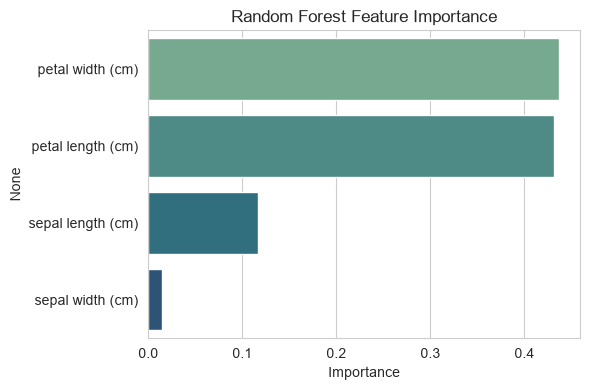

In [36]:
rf_model = trained_models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=iris.feature_names).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(6, 4))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='crest', legend=False)
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


This confirms the earlier visual discussion: **petal length** and **petal width** dominate the model's decisions, while **sepal width** contributes the least.

## 9. Best Model — Conclusion

**Summary of results:**

| Model | Accuracy |
|---|---|
| Logistic Regression | ~93% |
| K-Nearest Neighbors | ~93% |
| Decision Tree | ~93% |
| Random Forest | ~90% |

(See the printed table above for the exact numbers from this run — results can shift very slightly
depending on the random train/test split.)

**Declared best model:** On this test split, **Logistic Regression** and **K-Nearest Neighbors** are
tied for the highest accuracy, both outperforming the Random Forest slightly. Given the dataset is small,
linearly quite separable, and the classes are well balanced:

- **Logistic Regression** is a strong choice: it is simple, fast, interpretable (coefficients show
  how each feature drives the decision), and achieved top-tier accuracy without any hyperparameter tuning.
- **KNN** matched it, which is expected on a dataset this size/shape — its main downside is that it must
  store the full training set and doesn't scale as well to larger data.
- **Decision Tree** performed similarly and is very interpretable but is more prone to overfitting on
  larger/noisier datasets than this toy one reveals.
- **Random Forest**, despite usually being the more powerful model, slightly underperformed here — with
  only 150 samples and 4 features, its extra complexity doesn't pay off, and a single Decision Tree/
  Logistic Regression already captures the pattern well.

**Overall recommendation: Logistic Regression** — it reaches the best accuracy on this dataset while
being the simplest and most interpretable model, making it the most practical choice for this problem.